# Addict-Fatigue Simulation Walkthrough

This notebook walks through the simulation module in `/Users/iamsikun/Desktop/research/recsys/src/recsys/simulation/addict_fatigue.py` step by step.

Coverage in this notebook:
- Section 2.1: user heterogeneity draws
- Section 2.2: item embeddings with cluster structure
- Section 2.3: fatigue and habit state evolution
- Section 2.4: click and continuation outcomes
        


In [1]:
%run _dev_setup.py

🔁 Autoreload is ON (IPython detected).
✅ Using recsys from: /Users/iamsikun/Desktop/research/recsys/src/recsys


In [5]:
import numpy as np
import pandas as pd


In [6]:
import matplotlib.pyplot as plt
plt.style.use('default')

In [4]:
from recsys.simulation import AddictFatigueConfig, AddictFatigueSimulator

## 1) Configure The DGP

`AddictFatigueConfig` contains all structural parameters from Sections 2.1-2.4.
        


In [8]:
cfg = AddictFatigueConfig(
    n_users=600,
    n_items=500,
    embedding_dim=8,
    horizon=30,
    n_clusters=6,
    cluster_std=0.30,
    mu_lambda=-0.1,
    sigma_lambda=0.5,
    mu_delta_f=-0.2,
    sigma_delta_f=0.7,
    sigma_eta=0.35,
    delta_g=0.18,
    kappa0=-0.4,
    kappa1=1.1,
    sigma_u=0.5,
    alpha0=0.25,
    alpha1=1.0,
    xi=0.65,
    seed=42,
)

cfg

AddictFatigueConfig(n_users=600, n_items=500, embedding_dim=8, horizon=30, n_clusters=6, cluster_std=0.3, cluster_weights=None, mu_lambda=-0.1, sigma_lambda=0.5, mu_delta_f=-0.2, sigma_delta_f=0.7, sigma_eta=0.35, delta_g=0.18, kappa0=-0.4, kappa1=1.1, sigma_u=0.5, alpha0=0.25, alpha1=1.0, xi=0.65, seed=42)

In [9]:
sim = AddictFatigueSimulator(cfg)

## 2) Section 2.1 Users

Draw user-level latent parameters:
- `theta_i` (long-run interests)
- `lambda_i` (fatigue sensitivity)
- `delta_Fi` (fatigue decay)
- `eta_i` (habit sensitivity)
        


In [10]:
users = sim.sample_users()

print('theta shape:', users.theta.shape)
print('lambda shape:', users.fatigue_sensitivity.shape)
print('delta_F shape:', users.fatigue_decay.shape)
print('eta shape:', users.habit_sensitivity.shape)
        


theta shape: (600, 8)
lambda shape: (600,)
delta_F shape: (600,)
eta shape: (600,)


In [15]:
user_summary = pd.DataFrame(
    {
        'lambda_i': users.fatigue_sensitivity,
        'delta_Fi': users.fatigue_decay,
        'eta_i': users.habit_sensitivity,
    }
).describe().T

user_summary

,count,mean,std,min,25%,50%,75%,max
lambda_i,600.0,1.020153,0.542257,0.215497,0.637304,0.903804,1.260289,4.575104
delta_Fi,600.0,0.465090,0.158819,0.036531,0.355476,0.470840,0.572318,0.885514
eta_i,600.0,0.286575,0.218547,0.001939,0.100822,0.247398,0.419360,1.085660


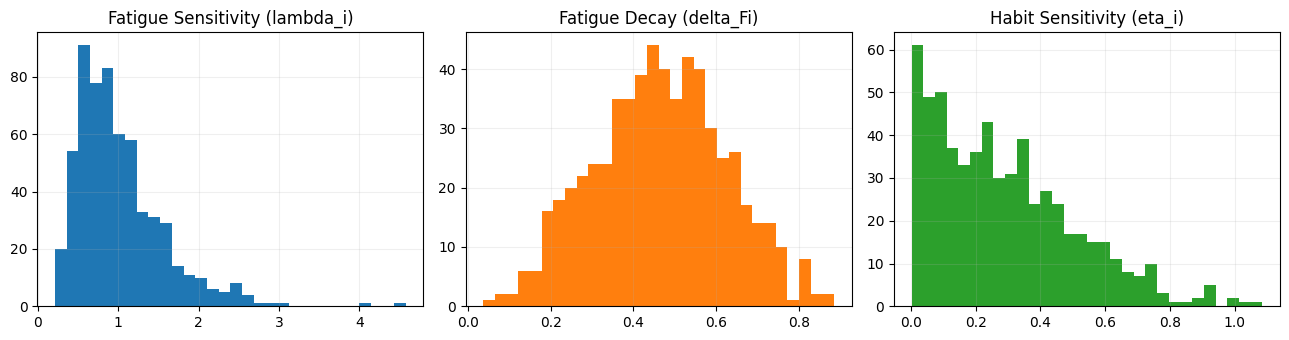

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].hist(users.fatigue_sensitivity, bins=30, color='#1f77b4')
axes[0].set_title('Fatigue Sensitivity (lambda_i)')

axes[1].hist(users.fatigue_decay, bins=30, color='#ff7f0e')
axes[1].set_title('Fatigue Decay (delta_Fi)')

axes[2].hist(users.habit_sensitivity, bins=30, color='#2ca02c')
axes[2].set_title('Habit Sensitivity (eta_i)')

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 3) Section 2.2 Items

Items are generated from a Gaussian mixture (clustered semantic regions), then row-normalized so `||a_j||=1`.
        


In [17]:
items = sim.sample_items()

print('embeddings shape:', items.embeddings.shape)
print('cluster_ids shape:', items.cluster_ids.shape)
print('cluster_centers shape:', items.cluster_centers.shape)

embeddings shape: (500, 8)
cluster_ids shape: (500,)
cluster_centers shape: (6, 8)


In [22]:
embedding_norms = np.linalg.norm(items.embeddings, axis=1)
print('embedding norm min/max:', float(embedding_norms.min()), float(embedding_norms.max()))

cluster_counts = pd.Series(items.cluster_ids).value_counts().sort_index()
cluster_counts.index.name = 'cluster'
cluster_counts.name = 'n_items'
cluster_counts

embedding norm min/max: 0.9999999999999998 1.0000000000000002


cluster
0     77
1     83
2     75
3    102
4     85
5     78
Name: n_items, dtype: int64

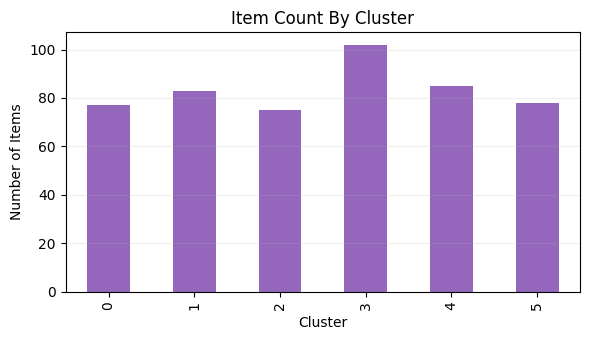

In [20]:
fig, ax = plt.subplots(figsize=(6, 3.5))
cluster_counts.plot(kind='bar', ax=ax, color='#9467bd')
ax.set_title('Item Count By Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Items')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 4) Section 2.3-2.4 Rollout

For now we use uniform random actions as a placeholder policy. The structural dynamics still follow the Section 2.3 and 2.4 equations.
        


In [23]:
actions = sim.sample_uniform_actions()
rollout = sim.simulate(actions=actions, users=users, items=items)

print('actions:', rollout.actions.shape)
print('clicks:', rollout.clicks.shape)
print('continuation:', rollout.continuation.shape)
print('fatigue_state:', rollout.fatigue_state.shape)
print('habit_state:', rollout.habit_state.shape)

actions: (600, 30)
clicks: (600, 30)
continuation: (600, 30)
fatigue_state: (600, 31, 8)
habit_state: (600, 31)


In [24]:
print('active users at t=1:', int(rollout.active[:, 0].sum()))
print('active users at t=T:', int(rollout.active[:, -1].sum()))
print('overall click rate:', float(rollout.clicks.mean()))
print('overall continuation rate:', float(rollout.continuation.mean()))

active users at t=1: 600
active users at t=T: 3
overall click rate: 0.041833333333333333
overall continuation rate: 0.05488888888888889


### Verify The Equations For One User-Time Pair

We recompute click and continuation logits manually and compare to stored probabilities.
        


In [25]:
i = 0
t = 0

item_id = rollout.actions[i, t]
a_t = rollout.items.embeddings[item_id]
F_t = rollout.fatigue_state[i, t]
G_t = rollout.habit_state[i, t]

relevance = float(users.theta[i] @ a_t)
fatigue_index = float(F_t @ a_t)
fatigue_norm = float(np.linalg.norm(F_t))
u_t = float(rollout.click_shock[i, t])

click_logit = (
    cfg.kappa0
    + cfg.kappa1 * relevance
    - users.fatigue_sensitivity[i] * fatigue_index
    + users.habit_sensitivity[i] * G_t
    + u_t
)
click_prob_manual = 1.0 / (1.0 + np.exp(-click_logit))

cont_logit = (
    cfg.alpha0
    + cfg.alpha1 * rollout.clicks[i, t]
    + users.habit_sensitivity[i] * G_t
    - cfg.xi * fatigue_norm
)
cont_prob_manual = 1.0 / (1.0 + np.exp(-cont_logit))

print('stored click prob: ', rollout.click_prob[i, t])
print('manual click prob: ', click_prob_manual)
print('stored cont prob:  ', rollout.continuation_prob[i, t])
print('manual cont prob:  ', cont_prob_manual)

stored click prob:  0.7282745023348602
manual click prob:  0.7282745023348602
stored cont prob:   0.7772998611746911
manual cont prob:   0.7772998611746911


## 5) Aggregate Process Diagnostics

These time paths make it easier to see short-run engagement vs fatigue accumulation.
        


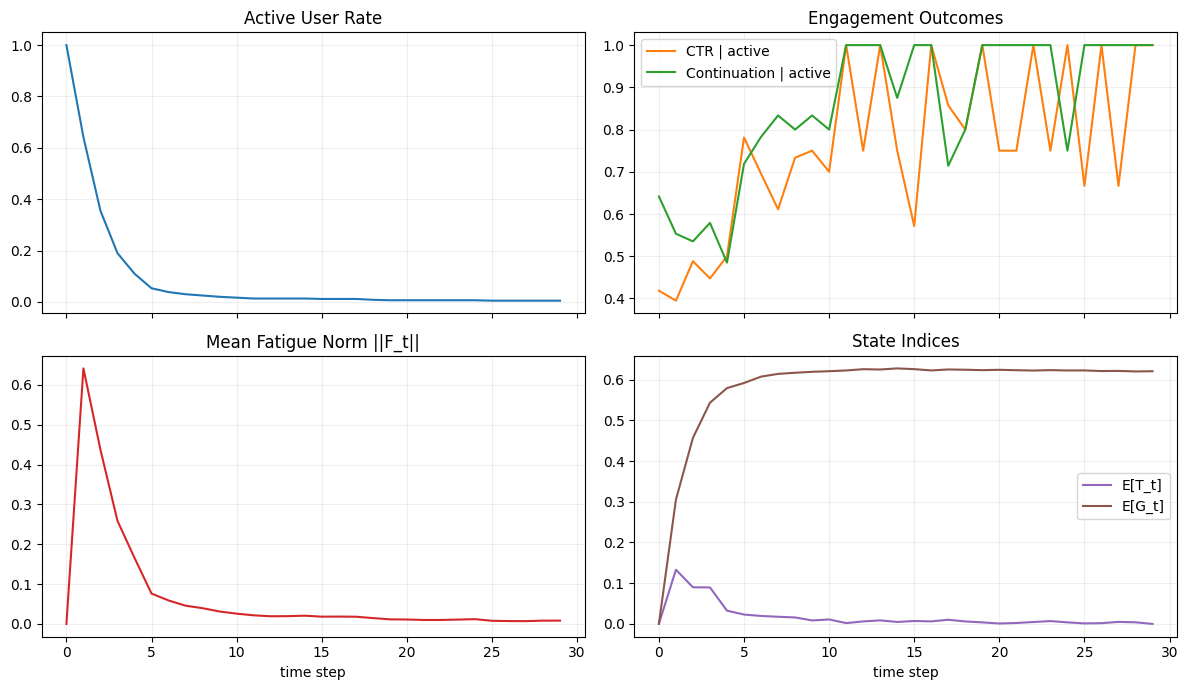

In [26]:
active_rate_t = rollout.active.mean(axis=0)
ctr_t = np.divide(
    rollout.clicks.sum(axis=0),
    np.maximum(rollout.active.sum(axis=0), 1),
)
cont_rate_t = np.divide(
    rollout.continuation.sum(axis=0),
    np.maximum(rollout.active.sum(axis=0), 1),
)
fatigue_t = rollout.fatigue_norm.mean(axis=0)
fatigue_index_t = rollout.fatigue_index.mean(axis=0)
habit_t = rollout.habit_state[:, :-1].mean(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

axes[0, 0].plot(active_rate_t, color='#1f77b4')
axes[0, 0].set_title('Active User Rate')
axes[0, 0].grid(alpha=0.2)

axes[0, 1].plot(ctr_t, label='CTR | active', color='#ff7f0e')
axes[0, 1].plot(cont_rate_t, label='Continuation | active', color='#2ca02c')
axes[0, 1].set_title('Engagement Outcomes')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.2)

axes[1, 0].plot(fatigue_t, color='#d62728')
axes[1, 0].set_title('Mean Fatigue Norm ||F_t||')
axes[1, 0].grid(alpha=0.2)

axes[1, 1].plot(fatigue_index_t, label='E[T_t]', color='#9467bd')
axes[1, 1].plot(habit_t, label='E[G_t]', color='#8c564b')
axes[1, 1].set_title('State Indices')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.2)

for ax in axes[1]:
    ax.set_xlabel('time step')

plt.tight_layout()
plt.show()

## 6) Single-User Trajectory Example

A concrete path helps debug absorbing exit and state updates.
        


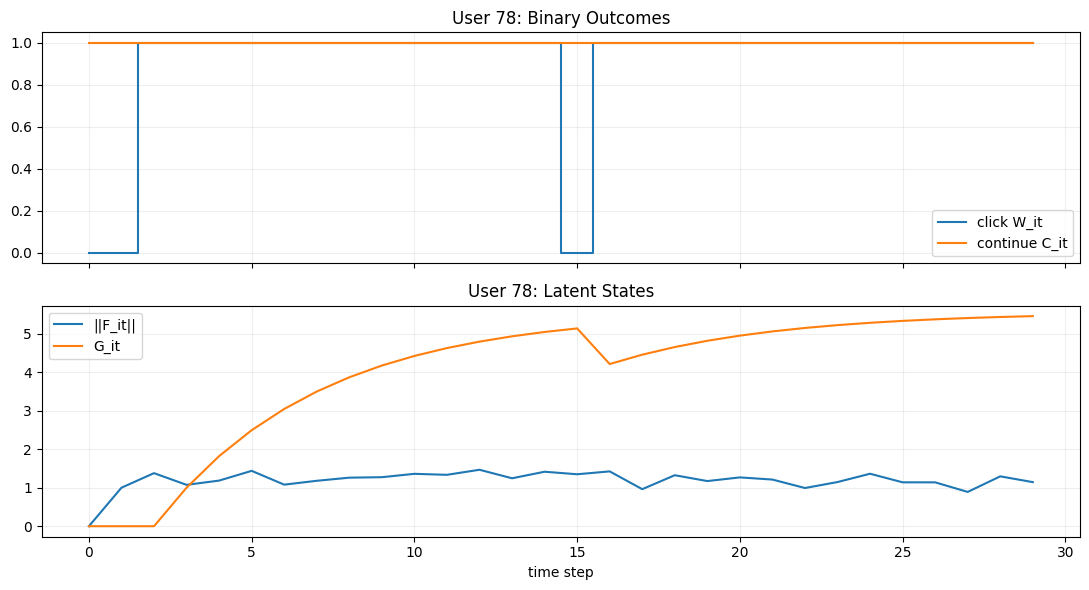

In [27]:
# pick a user who survives at least a few steps
alive_steps = rollout.active.sum(axis=1)
user_id = int(np.argmax(alive_steps))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].step(range(cfg.horizon), rollout.clicks[user_id], where='mid', label='click W_it')
axes[0].step(range(cfg.horizon), rollout.continuation[user_id], where='mid', label='continue C_it')
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title(f'User {user_id}: Binary Outcomes')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(rollout.fatigue_norm[user_id], label='||F_it||')
axes[1].plot(rollout.habit_state[user_id, :-1], label='G_it')
axes[1].set_title(f'User {user_id}: Latent States')
axes[1].set_xlabel('time step')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7) Build A Tidy Event Table

Useful for later estimation experiments.
        


In [28]:
def to_event_table(rollout):
    n_users, horizon = rollout.actions.shape
    user_id = np.repeat(np.arange(n_users), horizon)
    t = np.tile(np.arange(horizon), n_users)

    df = pd.DataFrame(
        {
            'user_id': user_id,
            't': t,
            'active': rollout.active.reshape(-1),
            'action': rollout.actions.reshape(-1),
            'click': rollout.clicks.reshape(-1),
            'continue': rollout.continuation.reshape(-1),
            'reward': rollout.rewards.reshape(-1),
            'click_prob': rollout.click_prob.reshape(-1),
            'continuation_prob': rollout.continuation_prob.reshape(-1),
            'fatigue_index': rollout.fatigue_index.reshape(-1),
            'fatigue_norm': rollout.fatigue_norm.reshape(-1),
            'habit_state': rollout.habit_state[:, :-1].reshape(-1),
        }
    )
    return df


events = to_event_table(rollout)
events.head(10)

,user_id,t,active,action,click,continue,reward,click_prob,continuation_prob,fatigue_index,fatigue_norm,habit_state
0,0,0,1,478,1,1,1,0.728275,0.777300,0.000000,0.000000,0.00
1,0,1,1,393,1,1,1,0.790053,0.663469,-0.265721,1.000000,1.00
2,0,2,1,495,0,0,0,0.581328,0.432784,0.464214,1.021385,1.82
3,0,3,0,286,0,0,0,0.000000,0.000000,0.000000,0.000000,1.82
4,0,4,0,378,0,0,0,0.000000,0.000000,0.000000,0.000000,1.82
5,0,5,0,82,0,0,0,0.000000,0.000000,0.000000,0.000000,1.82
6,0,6,0,149,0,0,0,0.000000,0.000000,0.000000,0.000000,1.82
7,0,7,0,86,0,0,0,0.000000,0.000000,0.000000,0.000000,1.82
8,0,8,0,468,0,0,0,0.000000,0.000000,0.000000,0.000000,1.82
9,0,9,0,307,0,0,0,0.000000,0.000000,0.000000,0.000000,1.82


## Next Step

The module now supports Sections 2.1-2.4 end to end. The next extension is to replace uniform actions with the candidate generation and logging policy in Section 2.5.
        
